In [1]:
from intersection2d_sim import Simulator
from pedestrian_agent import Agent, Agent2D

import numpy as np


In [ ]:

from mm_mpc_inter2d import MM_MPC_TI
from uncontrolled_agent import UncontrolledAgent





ev_noise_std=[0.01,0.01]
tv_noise_std=[0.2, 0.2]
ev=Agent2D(role='EV', dt=0.2, cl=3, state=np.array([5, 6.5,0 ]), noise_std=ev_noise_std)
                    
agents=[Agent(role='TV', dt=0.2, cl=4, state=np.array([6, 0]), noise_std=tv_noise_std) for i in range(1)]
agents.append(Agent(role='ped', dt=0.15, cl=7, state=np.array([0., 3.]), noise_std=tv_noise_std, s_dec = 7))
                    
# agents.append(Agent(role='ped', cl=7, state=np.array([0., 4.]), noise_std=tv_noise_std, s_dec = 12))
# agents.append(Agent(role='ped', cl=9, state=np.array([0., 2.]), noise_std=tv_noise_std, s_dec = 12))

tv_n_stds=[v.noise_std for v in agents]
agents.append(ev)
Sim=Simulator(agents, T_FINAL=80)

N=9

Sim.set_MPC_N(N)

initial_states = [[0.0, 2.0]]
final_states = [[100.0, 4.0]]



cost_func_params = {
    'Q': np.array([[7.0, 0.0, 0.0], [0.0, 7.0, 0.0], [0.0, 0.0, 2.5]]),
    'R': np.array([[.75, 0.0], [0.0, .5]]),
    'P': np.array([[12.5, 0.0], [0.0, 12.5]]),
    'Qc': 8,
    'kappa': 3 
}
mpc_params = {
    'num_agents': 1,
    'dt': 0.2,
    'N' : N,
    'rob_dia': 0.3,
    'v_lim': 8.0,
    'omega_lim': 1.0,
    'total_sim_timestep': 200,
    'obs_sim_timestep': 100,
    'epsilon_o': 0.05,
    'epsilon_r': 0.05,
    'safety_margin': 0.05,
    'goal_tolerence': 0.2, 
    'linearized_ca': False
}
obs_traj = []
static_obs = []

obs = {"static": static_obs, "dynamic": obs_traj}

num_trials = 1
algs = ["MPC"]
vel_var_levels = [0.05, 0.4]
rationality = 0.5
T = 6
y_pos = 3

scenario = "test"
trial = 1
uncontrolled_fleet = UncontrolledAgent(init_state=[(0, 0, -np.pi/2)], dt=mpc_params['dt'], H=mpc_params['dt']*mpc_params['N'], action_variance=0.2)
uncontrolled_fleet_data = uncontrolled_fleet.simulate_diff_drive()

mpc = MM_MPC_TI(initial_states, final_states, cost_func_params, obs, mpc_params, scenario, trial, uncontrolled_fleet, uncontrolled_fleet_data, map=map, feedback=True, robust_horizon=4, ref=None)
# mpc = MM_MPC_TI(initial_states, final_states, cost_func_params, obs, mpc_params, scenario, trial, uncontrolled_agent, uncontrolled_traj)
mpc.simulate(Sim)

0

******************************************************************************
This program contains Ipopt, a library for large-scale nonlinear optimization.
 Ipopt is released as open source code under the Eclipse Public License (EPL).
         For more information visit https://github.com/coin-or/Ipopt
******************************************************************************

Agent 0 Solve Time: 2.8183786869049072
Infeasible solve
Agent state:  [46.31648  6.66484]  Agent control:  [[ 0.82419 -0.     ]
 [ 0.70027 -0.     ]
 [ 0.51152 -0.     ]
 [ 0.3085  -0.     ]
 [ 0.13371 -0.     ]
 [ 0.02182 -0.     ]
 [-0.      -0.     ]
 [-0.      -0.     ]
 [-0.00002 -0.     ]]
1
Agent 0 Solve Time: 2.403480052947998
Infeasible solve
Agent state:  [47.66173  6.78763]  Agent control:  [[ 0.61395 -0.     ]
 [ 0.50238 -0.     ]
 [ 0.3384  -0.     ]
 [ 0.17279 -0.     ]
 [ 0.0483  -0.     ]
 [ 0.      -0.     ]
 [-0.      -0.     ]
 [-0.      -0.     ]
 [-0.00003 -0.     ]]
2


CasADi - 2025-04-03 11:56:46 WARNING("KeyboardInterruptException") [.../casadi/interfaces/ipopt/ipopt_nlp.cpp:114]


Infeasible solve
Agent state:  [48.97926  6.38763]  Agent control:  [[-2.  0.]
 [-2.  0.]
 [-2.  0.]
 [-2.  0.]
 [-2.  0.]
 [-2.  0.]
 [-2.  0.]
 [-2.  0.]
 [-2.  0.]]
Resetting agent: 1
Reached 1.3975458114978991
3
Agent 0 Solve Time: 2.0423476696014404
Infeasible solve
Agent state:  [50.27584  6.57827]  Agent control:  [[ 0.95321 -0.     ]
 [ 0.8233  -0.     ]
 [ 0.62252 -0.     ]
 [ 0.40134 -0.     ]
 [ 0.20213 -0.     ]
 [ 0.05937 -0.     ]
 [ 0.      -0.     ]
 [-0.      -0.     ]
 [-0.00002 -0.     ]]
4
Agent 0 Solve Time: 2.3860151767730713
Infeasible solve
Agent state:  [51.60613  6.72459]  Agent control:  [[ 0.73159 -0.     ]
 [ 0.61231 -0.     ]
 [ 0.43286 -0.     ]
 [ 0.2439  -0.     ]
 [ 0.088   -0.     ]
 [ 0.      -0.     ]
 [-0.      -0.     ]
 [-0.      -0.     ]
 [-0.00003 -0.     ]]
5
Agent 0 Solve Time: 2.288841962814331
Infeasible solve
Agent state:  [52.9617   6.83114]  Agent control:  [[ 0.53275 -0.     ]
 [ 0.4265  -0.     ]
 [ 0.27321 -0.     ]
 [ 0.12371 -0.   

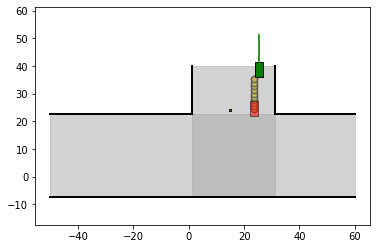

In [3]:
import matplotlib.pyplot as plt
import matplotlib.transforms as tf
from celluloid import Camera
from IPython.display import HTML
import pdb

fig, ax= plt.subplots()
camera = Camera(fig)

for  i in range(Sim.t):
    Sim.draw_intersection(ax, i)
    camera.snap()

animation = camera.animate(repeat = True, repeat_delay = 100)
HTML(animation.to_html5_video())

In [1]:
from intersection_sim import Simulator
from pedestrian_agent import Agent
from mm_mpc_inter import MM_MPC_TI
from uncontrolled_agent import UncontrolledAgent

import numpy as np



ev_noise_std=[0.0001,0.0001]
ev=Agent(role='EV', state=np.array([50, 7.]), cl=3, noise_std=ev_noise_std)
tv_noise_std=[0.1, 0.1]
agents=[Agent(role='TV', cl=4, state=np.array([35, 0.]), noise_std=tv_noise_std) for i in range(1)]
# agents.append(Agent(role='ped', cl=7, state=np.array([0., 4.]), noise_std=tv_noise_std, s_dec = 12))
# agents.append(Agent(role='ped', cl=9, state=np.array([0., 2.]), noise_std=tv_noise_std, s_dec = 12))

tv_n_stds=[v.noise_std for v in agents]
agents.append(ev)
Sim=Simulator(agents, T_FINAL=50)

N=16

# Sim.T+=10
Sim.set_MPC_N(N)

initial_states = [[0.0, 2.0]]
final_states = [[100.0, 4.0]]



cost_func_params = {
    'Q': np.array([[7.0, 0.0, 0.0], [0.0, 7.0, 0.0], [0.0, 0.0, 2.5]]),
    'R': np.array([[.75, 0.0], [0.0, .5]]),
    'P': np.array([[12.5, 0.0], [0.0, 12.5]]),
    'Qc': 8,
    'kappa': 3 
}
mpc_params = {
    'num_agents': 1,
    'dt': 0.2,
    'N' : N,
    'rob_dia': 0.3,
    'v_lim': 8.0,
    'omega_lim': 1.0,
    'total_sim_timestep': 200,
    'obs_sim_timestep': 100,
    'epsilon_o': 0.05,
    'epsilon_r': 0.05,
    'safety_margin': 0.05,
    'goal_tolerence': 0.2, 
    'linearized_ca': True
}
obs_traj = []
static_obs = []

obs = {"static": static_obs, "dynamic": obs_traj}

num_trials = 1
algs = ["MPC"]
vel_var_levels = [0.05, 0.4]
rationality = 0.5
T = 6
y_pos = 3

scenario = "test"
trial = 1
uncontrolled_fleet = UncontrolledAgent(init_state=[(0, 0, -np.pi/2)], dt=mpc_params['dt'], H=mpc_params['dt']*mpc_params['N'], action_variance=0.2)
uncontrolled_fleet_data = uncontrolled_fleet.simulate_diff_drive()

mpc = MM_MPC_TI(initial_states, final_states, cost_func_params, obs, mpc_params, scenario, trial, uncontrolled_fleet, uncontrolled_fleet_data, map=map, feedback=False, robust_horizon=2, ref=None)
# mpc = MM_MPC_TI(initial_states, final_states, cost_func_params, obs, mpc_params, scenario, trial, uncontrolled_agent, uncontrolled_traj)
mpc.simulate(Sim)

0
Infeasible solve
Agent state:  [51.59375  5.75   ]  Agent control:  [[-5.]
 [-5.]
 [-5.]
 [-5.]
 [-5.]
 [-5.]
 [-5.]
 [-5.]
 [-5.]
 [-5.]
 [-5.]
 [-5.]
 [-5.]
 [-5.]
 [-5.]
 [-5.]]
1
Infeasible solve
Agent state:  [52.875  4.5  ]  Agent control:  [[-5.]
 [-5.]
 [-5.]
 [-5.]
 [-5.]
 [-5.]
 [-5.]
 [-5.]
 [-5.]
 [-5.]
 [-5.]
 [-5.]
 [-5.]
 [-5.]
 [-5.]
 [-5.]]
2
Infeasible solve
Agent state:  [53.84375  3.25   ]  Agent control:  [[-5.]
 [-5.]
 [-5.]
 [-5.]
 [-5.]
 [-5.]
 [-5.]
 [-5.]
 [-5.]
 [-5.]
 [-5.]
 [-5.]
 [-5.]
 [-5.]
 [-5.]
 [-5.]]
3
Infeasible solve
Agent state:  [54.5  2. ]  Agent control:  [[-5.]
 [-5.]
 [-5.]
 [-5.]
 [-5.]
 [-5.]
 [-5.]
 [-5.]
 [-5.]
 [-5.]
 [-5.]
 [-5.]
 [-5.]
 [-5.]
 [-5.]
 [-5.]]
4
Infeasible solve
Agent state:  [54.84375  0.75   ]  Agent control:  [[-5.]
 [-5.]
 [-5.]
 [-5.]
 [-5.]
 [-5.]
 [-5.]
 [-5.]
 [-5.]
 [-5.]
 [-5.]
 [-5.]
 [-5.]
 [-5.]
 [-5.]
 [-5.]]
5
Infeasible solve
Agent state:  [54.875 -0.05 ]  Agent control:  [[-5.]
 [-5.]
 [-5.]
 [-5.]
 [-

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.transforms as tf
from celluloid import Camera
from IPython.display import HTML
import pdb

fig, ax= plt.subplots()
camera = Camera(fig)

for  i in range(Sim.t):
    Sim.draw_intersection(ax, i)
    camera.snap()

animation = camera.animate(repeat = True, repeat_delay = 100)
HTML(animation.to_html5_video())